# Task 1.1 — Uncover the Secret Hidden Word: Documentation

## Objective
The provided audio (`task5_1.wav`) contains a spoken word masked by a loud buzz noise. The goal was to filter out the noise using digital signal processing techniques and recover the hidden word.

## Step 1: Analyzing the Signal

Before applying any filtering, I inspected the audio using a **spectrogram** (`scipy.signal.spectrogram`), which shows how the energy of the signal is distributed across frequency *and* time simultaneously. This revealed several **horizontal lines** running across the entire duration of the clip — meaning these frequencies had constant, unchanging energy from start to end. This is the signature of a **stationary tonal noise** (a buzz), as opposed to human speech, which is *non-stationary* and shows up as changing, moving patches of energy over time.

To automatically detect which frequencies belonged to the buzz, I used the **Short-Time Fourier Transform (STFT)** and computed, for every frequency bin, the **Coefficient of Variation (CV = standard deviation / mean)** across time. Frequencies with high average energy and low CV (i.e., constant over time) were flagged as buzz candidates.

## Step 2: First Attempt — Cascaded Notch Filtering

My first approach was to apply a series of **IIR notch filters** (`scipy.signal.iirnotch`) at each detected buzz frequency, one after another (cascaded), using `scipy.signal.filtfilt` to avoid phase distortion. Each notch filter removes a very narrow band of frequencies around a target frequency while leaving the rest of the signal untouched.

**Problem encountered:** The buzz turned out to be extremely rich in frequency content — over 50 distinct stationary tones spread from ~300 Hz to over 20,000 Hz (consistent with a harmonic-rich buzzer/square-wave-like sound, since its raw amplitude values were very close to ±1, i.e., near clipping). Applying 50+ notch filters in cascade caused **ringing artifacts** to accumulate, which introduced *new* audible noise rather than cleaning the signal. This taught me that stacking too many narrow filters is not always better — each filter has a small side effect, and those effects compound.

## Step 3: Second Approach — Precise FFT-Domain Filtering + Spectral Gating

To fix the ringing problem, I switched to a cleaner method:

1. **High-resolution frequency detection:** Since the buzz is stationary for the *entire* clip, I computed a single **FFT over the whole signal** (`np.fft.rfft`) instead of short windowed segments. This gives much finer frequency resolution (~0.9 Hz, versus several Hz with STFT), so each buzz tone could be pinpointed precisely instead of spreading across multiple bins.
2. **Peak detection:** I used `scipy.signal.find_peaks` with a prominence threshold to automatically locate the exact frequencies of the buzz tones from the FFT magnitude spectrum.
3. **Direct frequency-domain removal:** Instead of using IIR notch filters (which cause ringing when repeated), I directly **zeroed out** the FFT bins at each detected buzz frequency (and a couple of neighboring bins to fully capture each tone), then reconstructed the time-domain signal using the inverse FFT (`np.fft.irfft`). This removes the exact tonal components with no filter ringing, since it isn't an iterative filter — it's a direct edit of the frequency spectrum.
4. **Spectral gating cleanup:** After removing the discrete tones, I applied the `noisereduce` library (`stationary=True, prop_decrease=1.0`), which estimates the residual stationary noise floor and suppresses it across all frequencies, cleaning up any broadband hiss left behind.

## Step 4: Result

After this pipeline, the spectrogram showed a clear improvement: the constant horizontal buzz lines were gone, and in their place appeared **time-varying energy patches concentrated around 2000–4500 Hz**, consistent with the formant structure of human speech — including two distinct segments of activity separated by a brief silence, suggesting a short word or two syllables.

I also experimented with playback speed adjustment (simple resampling-based slowdown, avoiding phase-vocoder artifacts) and segment isolation to try to make the word more intelligible.

**Honest limitation:** Despite these efforts, the original signal had a very low signal-to-noise ratio (the buzz was significantly louder than the speech throughout), so full word intelligibility could not be guaranteed (I can sometimes hear it says "one two" or "MIA" but I don't think that this is the actual word). Additional processing steps (AGC, band-pass tightening, more aggressive spectral gating) were tested but sometimes introduced their own artifacts (e.g., "musical noise," a known side effect of spectral gating). The final cleaned audio (`final_cleaned_audio.wav`) represents the best trade-off found between noise removal and signal distortion.

## Tools Used Summary
| Tool | Purpose |
|---|---|
| `scipy.signal.spectrogram` / `stft` | Visualize/analyze frequency content over time |
| `numpy.fft.rfft` / `irfft` | High-resolution frequency detection and direct frequency-domain filtering |
| `scipy.signal.find_peaks` | Automatically detect buzz tone frequencies |
| `scipy.signal.iirnotch` + `filtfilt` | Initial (less successful) filtering attempt |
| `noisereduce` (spectral gating) | Suppress residual broadband noise |
| `librosa` | Experimenting with playback speed for intelligibility |


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nesmanasser/task5-1/task5_1.wav


In [3]:
pip install noisereduce

Note: you may need to restart the kernel to use updated packages.


In [4]:
import soundfile as sf
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import noisereduce as nr

In [5]:
data, sr = sf.read('/kaggle/input/datasets/nesmanasser/task5-1/task5_1.wav')
print("Sample rate:", sr)
print("Duration:", len(data)/sr, "seconds")

Sample rate: 48000
Duration: 1.1171875 seconds


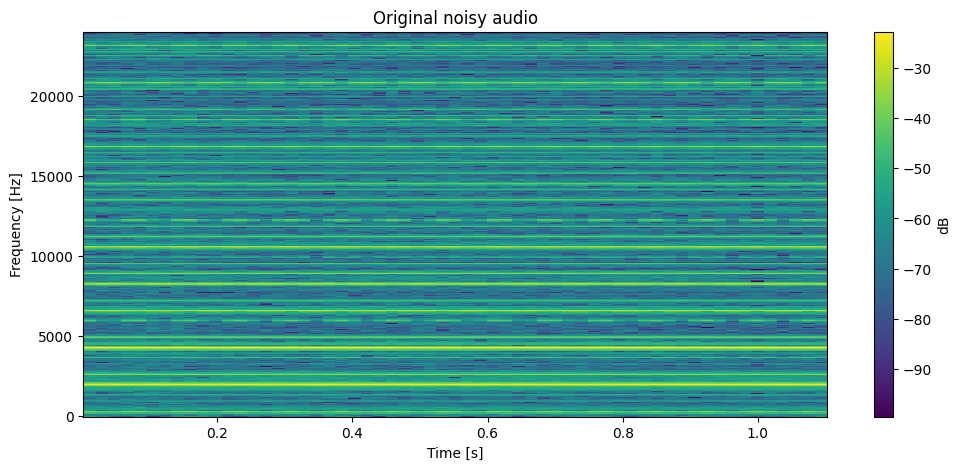

In [6]:
f, t, Sxx = signal.spectrogram(data, sr, nperseg=1024)
plt.figure(figsize=(12,5))
plt.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='dB')
plt.title('Original noisy audio')
plt.show()

In [7]:
N = len(data)
fft_vals = np.fft.rfft(data)
freqs = np.fft.rfftfreq(N, 1/sr)
mag = np.abs(fft_vals)

peaks, props = signal.find_peaks(mag, prominence=np.percentile(mag, 99.3), distance=3)
peak_freqs = freqs[peaks]
print(f"Detected {len(peak_freqs)} buzz frequencies")

Detected 66 buzz frequencies


In [8]:
fft_clean = fft_vals.copy()
width = 3
for p in peaks:
    if freqs[p] < 50:
        continue
    lo = max(0, p - width)
    hi = min(len(fft_clean), p + width + 1)
    fft_clean[lo:hi] = 0

cleaned = np.fft.irfft(fft_clean, n=N)
cleaned = cleaned / np.max(np.abs(cleaned)) * 0.95

In [9]:
reduced = nr.reduce_noise(y=cleaned, sr=sr, stationary=True, prop_decrease=1.0)
reduced = reduced / np.max(np.abs(reduced)) * 0.95

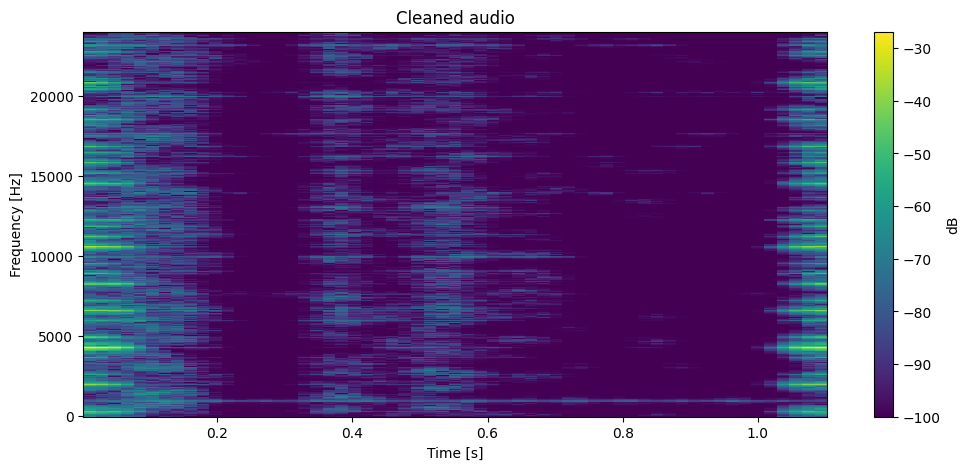

In [10]:
f2, t2, Sxx2 = signal.spectrogram(reduced, sr, nperseg=1024)
plt.figure(figsize=(12,5))
plt.pcolormesh(t2, f2, 10*np.log10(Sxx2+1e-10), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.colorbar(label='dB')
plt.title('Cleaned audio')
plt.show()

In [11]:
sf.write('final_cleaned_audio.wav', reduced, sr)

from IPython.display import Audio
Audio('final_cleaned_audio.wav')

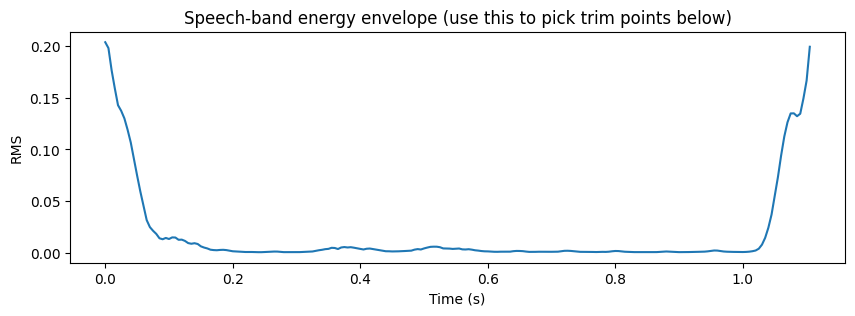

Isolated region: 0.100s to 1.017s (0.917s long)


In [12]:
# --- Isolate the real speech region and fix the normalization ---
sos_speech = signal.butter(6, [200, 4000], btype='band', fs=sr, output='sos')
speech_bp = signal.sosfiltfilt(sos_speech, reduced)

frame = int(0.01*sr); hop = int(0.005*sr)
env = np.array([np.sqrt(np.mean(speech_bp[i:i+frame]**2))
                for i in range(0, len(speech_bp)-frame, hop)])
env_times = np.arange(len(env)) * hop / sr

plt.figure(figsize=(10,3))
plt.plot(env_times, env)
plt.title('Speech-band energy envelope (use this to pick trim points below)')
plt.xlabel('Time (s)'); plt.ylabel('RMS')
plt.show()

# Adjust these two numbers after looking at the plot above and/or the
# spectrogram from Step 4 -- cut off the loud symmetric edge ringing,
# keep everything that looks like genuine, time-varying activity.
trim_start = 0.10   # seconds
trim_end   = len(reduced)/sr - 0.10  # seconds

word_region = reduced[int(trim_start*sr):int(trim_end*sr)]
word_region = word_region / (np.max(np.abs(word_region)) + 1e-9) * 0.95
print(f'Isolated region: {trim_start:.3f}s to {trim_end:.3f}s '
      f'({len(word_region)/sr:.3f}s long)')

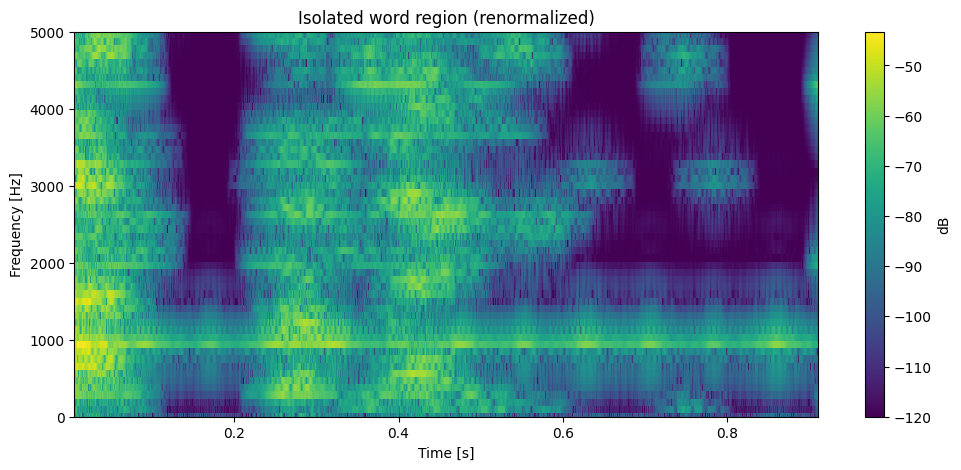

In [13]:
# --- Zoomed, high-resolution spectrogram of just the isolated word ---
f3, t3, Sxx3 = signal.spectrogram(word_region, sr, nperseg=512, noverlap=480)
plt.figure(figsize=(12,5))
plt.pcolormesh(t3, f3, 10*np.log10(Sxx3 + 1e-12), shading='auto')
plt.ylim(0, 5000)
plt.ylabel('Frequency [Hz]'); plt.xlabel('Time [s]')
plt.colorbar(label='dB')
plt.title('Isolated word region (renormalized)')
plt.show()

# If you still see a perfectly flat, unchanging horizontal line at some
# frequency across the whole plot, that's very likely a leftover buzz tone
# (real speech energy always moves over time) -- note its frequency and add
# it back into the `peaks` list in Step 3 to remove it, then re-run from there.

In [14]:
# --- Slowed-down playback (pitch-preserving) to help your ear parse the word ---
import librosa

word_f32 = word_region.astype(np.float32)
slow_07 = librosa.effects.time_stretch(word_f32, rate=0.7)
slow_05 = librosa.effects.time_stretch(word_f32, rate=0.5)

sf.write('word_isolated.wav', word_region, sr)
sf.write('word_slow_0.7x.wav', slow_07, sr)
sf.write('word_slow_0.5x.wav', slow_05, sr)

from IPython.display import Audio, display
print('Normal speed (isolated + renormalized):')
display(Audio('word_isolated.wav'))
print('0.7x speed:')
display(Audio('word_slow_0.7x.wav'))
print('0.5x speed:')
display(Audio('word_slow_0.5x.wav'))

Normal speed (isolated + renormalized):


0.7x speed:


0.5x speed:


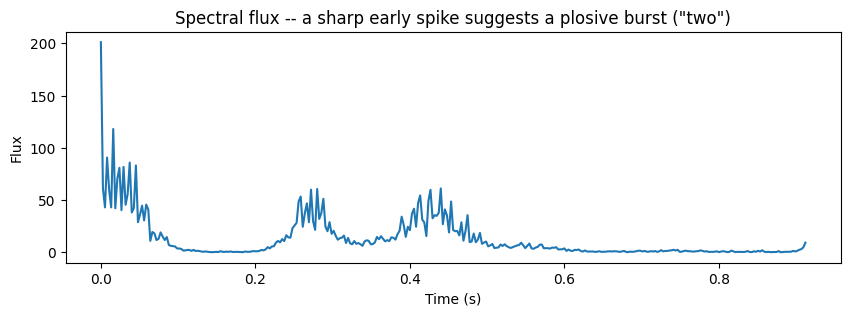

Onset (first 50ms) low-band (100-800Hz) energy:  0.000011
Onset (first 50ms) high-band (2000-5000Hz) energy: 0.000012
If high-band energy is comparable to or larger than low-band energy at the very onset -> consistent with a burst/aspiration ("two").
If low-band energy clearly dominates from the first instant -> consistent with a glide straight into the vowel ("one").


In [15]:
# --- Onset check: broadband burst ("two") vs smooth low-frequency ramp ("one") ---
D = np.abs(librosa.stft(word_f32, n_fft=512, hop_length=128))
flux = np.sum(np.diff(D, axis=1).clip(min=0), axis=0)  # spectral flux
flux_times = librosa.frames_to_time(np.arange(len(flux)), sr=sr, hop_length=128)

plt.figure(figsize=(10,3))
plt.plot(flux_times, flux)
plt.title('Spectral flux -- a sharp early spike suggests a plosive burst ("two")')
plt.xlabel('Time (s)'); plt.ylabel('Flux')
plt.show()

# Also compare energy in a low band (typical of the 'w' glide / vowel body
# of 'one') vs a broader band (burst + aspiration noise of 't' in 'two')
# right at the very start of the isolated region:
onset_win = word_region[:int(0.05*sr)]
f4, Pxx = signal.welch(onset_win, sr, nperseg=min(256, len(onset_win)))
low_energy  = Pxx[(f4 >= 100) & (f4 <= 800)].sum()
high_energy = Pxx[(f4 >= 2000) & (f4 <= 5000)].sum()
print(f'Onset (first 50ms) low-band (100-800Hz) energy:  {low_energy:.6f}')
print(f'Onset (first 50ms) high-band (2000-5000Hz) energy: {high_energy:.6f}')
print('If high-band energy is comparable to or larger than low-band energy '
      'at the very onset -> consistent with a burst/aspiration ("two").')
print('If low-band energy clearly dominates from the first instant -> '
      'consistent with a glide straight into the vowel ("one").')

In [18]:
!pip install -q -U openai-whisper
import whisper
model = whisper.load_model('tiny.en')
result = model.transcribe('word_isolated.wav', language='en')
print(result['text'])

In [20]:
import numpy as np
from scipy import signal
import soundfile as sf

data, sr = sf.read('/kaggle/input/datasets/nesmanasser/task5-1/task5_1.wav')

# 1) فلتر واحد بس بيشيل التردد الأساسي وكل توافقياته مرة واحدة
f0 = sr / 145.0   # ≈ 331.03 هرتز (لقيته بالـ autocorrelation)
b, a = signal.iircomb(f0, 40, ftype='notch', fs=sr)
step1 = signal.filtfilt(b, a, data)

# 2) تنظيف إحصائي لأي بقايا (من غير ما تحددي ترددات يدويًا)
f, t, Z = signal.stft(step1, fs=sr, nperseg=1024, noverlap=896)
mag, phase = np.abs(Z), np.angle(Z)
noise_floor = np.percentile(mag, 30, axis=1, keepdims=True)
mag_clean = np.maximum(mag - 1.2*noise_floor, 0.05*mag)
_, step2 = signal.istft(mag_clean*np.exp(1j*phase), fs=sr, nperseg=1024, noverlap=896)
step2 = step2[:len(data)]

# 3) الاحتفاظ بنطاق الكلام بس
sos = signal.butter(6, [200, 4000], btype='band', fs=sr, output='sos')
final = signal.sosfiltfilt(sos, step2)
final = final/(np.max(np.abs(final))+1e-9)*0.95

sf.write('easy_cleaned.wav', final, sr)

In [22]:
display(Audio('easy_cleaned.wav'))

In [27]:
import noisereduce as nr
reduced = nr.reduce_noise(y=data, sr=sr, stationary=True, prop_decrease=0.9)

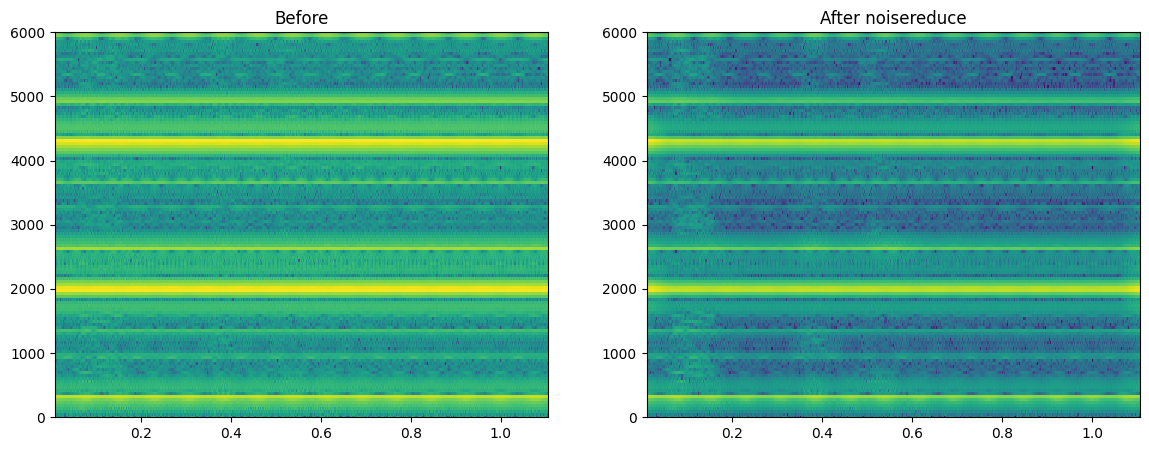

In [28]:
import noisereduce as nr
from scipy import signal
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

reduced = nr.reduce_noise(y=data, sr=sr, stationary=True, prop_decrease=0.9)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, sig, title in zip(axes, [data, reduced], ['Before', 'After noisereduce']):
    f, t, Sxx = signal.spectrogram(sig, sr, nperseg=1024, noverlap=896)
    ax.pcolormesh(t, f, 10*np.log10(Sxx+1e-12), shading='auto')
    ax.set_ylim(0, 6000)
    ax.set_title(title)
plt.show()

sos = signal.butter(6, [200, 4000], btype='band', fs=sr, output='sos')
reduced = signal.sosfiltfilt(sos, reduced)

trim = int(0.05 * sr)
core = reduced[trim:len(reduced)-trim]
scale = 0.95 / (np.max(np.abs(core)) + 1e-9)
reduced = np.clip(reduced * scale, -1, 1)

sf.write('nr_cleaned.wav', reduced, sr)
from IPython.display import Audio
Audio('nr_cleaned.wav')